# Online voltage control with topology change detection (13-bus showcase)

This notebook showcases how our method work with real-world loads and topology change.


## 1. Setup and paths


In [1]:
from pathlib import Path
import sys
import os

import numpy as np
import torch
import torch.nn.functional as F

# --- Repo root detection ---
repo_root = Path.cwd().resolve()
for _ in range(6):
    if (repo_root / "env" / "models").exists():
        break
    repo_root = repo_root.parent

assert (repo_root / "env" / "models").exists(), (
    "Could not locate repo root. Run this notebook from the varying_topo_online_opt folder."
)

# Keep relative paths consistent (plots, results)
os.chdir(repo_root)

# Make local modules importable without redefining any code
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "topo_est"))
sys.path.insert(0, str(repo_root / "utils"))

# Reproducibility
np.random.seed(18)
torch.manual_seed(18)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Output folders
output_dir = repo_root / "results"
figure_dir = repo_root / "figures"
output_dir.mkdir(exist_ok=True)
figure_dir.mkdir(exist_ok=True)

repo_root

PosixPath('/home/jason/Documents/research/varying_topo_online_opt')

## 2. Project imports (use existing implementations)


In [2]:
from scipy.io import loadmat

from env import create_13bus, IEEE13bus
from models import SafePolicyNetwork_SetPoint
from utils import create_RX_from_net

# Topology estimation / detection (from repo code)
from topo_est import topology_detection_lasso
from topo_est import topology_recovery

# Online optimization (from repo code)
from online_opt import online_update_Xp_NN

# Utility functions already implemented in this repo
from utils import collect_one_step, change_topo, err_cal, load_policy

# Plot helper
from utils import plot_trajectory_and_slopes

## 3. Load real load/PV profiles

We reuse the same load and PV profiles from `env/models` and apply the same resampling as the original notebook.


In [3]:
data_dir = repo_root / "env" / "models"

p_real = loadmat(str(data_dir / "aggr_p.mat"))["p"]
q_real = loadmat(str(data_dir / "aggr_q.mat"))["q"]

pv_p = loadmat(str(data_dir / "PV.mat"))["actual_PV_profile"]
# Match shapes to q_real
pv_p = np.resize(pv_p, (q_real.shape[0], 1))

# Downsample and then expand to align with the long simulation horizon
q_real = q_real[::3]
p_real = p_real[::3]
pv_p = pv_p[::3]

# to make the load/generation change slower than control
q_real = np.repeat(q_real, 6)
p_real = np.repeat(p_real, 6)
pv_p = np.repeat(pv_p, 6)

print(pv_p.shape, q_real.shape)

(28842,) (28842,)


## 4. Environment and helper setup

This section builds the 13-bus environment, sensitivity matrices, and initializes the online update buffers.


In [4]:
def build_env_and_params(seed=18):
    # Build the network and environment
    pp_net = create_13bus(str(repo_root / "env" / "models" / "case_13.mat"))

    injection_bus = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
    control_bus = np.array([2, 7, 9])

    n_control = len(control_bus)
    n_bus = len(injection_bus)

    # Cost weights (same as original notebook)
    C = np.asarray([1.2, 0.3, 0.6]) * 0.1
    coef_c = 0.02

    Q = np.eye(n_bus)
    R = np.eye(n_control)
    for i in range(n_control):
        R[i, i] = C[i] * coef_c

    # Controlled bus indices (0-based) for PyTorch indexing
    controller_id = [1, 6, 8]

    env = IEEE13bus(pp_net, injection_bus, injection_bus, Q=Q, R=R)
    state, _ = env.reset0(seed=seed)

    # Probing nodes (same as original)
    probing_nodes_id = [1, 3, 5, 6, 7, 8, 9, 10, 11]
    probing_nodes = [2, 4, 6, 7, 8, 9, 10, 11, 12]

    # Helper matrices to map between full bus space and controller space
    Phi_1 = torch.zeros((n_bus, n_control)).to(device)
    for i, bus_id in enumerate(controller_id):
        Phi_1[bus_id, i] = 1

    Phi_2 = torch.zeros((n_control, n_bus)).to(device)
    for i, bus_id in enumerate(controller_id):
        Phi_2[i, bus_id] = 1

    # Sensitivity matrices
    _, X = create_RX_from_net(pp_net, noise=0)
    X_full = X / np.square(4.16)
    X_sens = X_full[:, probing_nodes_id]
    _, lines = topology_recovery(X_sens, probing_nodes)

    probing_index = {bus_id: idx for idx, bus_id in enumerate(probing_nodes_id)}

    return {
        "env": env,
        "state": state,
        "injection_bus": injection_bus,
        "control_bus": control_bus,
        "controller_id": controller_id,
        "n_control": n_control,
        "n_bus": n_bus,
        "Q": Q,
        "R": R,
        "Phi_1": Phi_1,
        "Phi_2": Phi_2,
        "X_full": X_full,
        "X_sens": X_sens,
        "lines": lines,
        "probing_nodes_id": probing_nodes_id,
        "probing_nodes": probing_nodes,
        "probing_index": probing_index,
    }


def init_online_update_buffers(policy_list, n_control):
    # Collect unique parameter names once
    name_list = [name for name, _ in policy_list[0].named_parameters()]

    y_q_theta_dict = {}
    G_t_theta_dict = {}

    for name, param in policy_list[0].named_parameters():
        if len(param.data.shape) == 1:
            y_q_theta_dict[name] = torch.zeros((n_control, n_control * param.data.shape[0])).to(device)
            G_t_theta_dict[name] = torch.zeros((1, n_control * param.data.shape[0])).to(device)
        elif len(param.data.shape) == 2:
            y_q_theta_dict[name] = torch.zeros((n_control, n_control * param.data.shape[1])).to(device)
            G_t_theta_dict[name] = torch.zeros((1, n_control * param.data.shape[1])).to(device)
        else:
            raise ValueError("Unexpected parameter shape for online update buffers")

    return name_list, y_q_theta_dict, G_t_theta_dict


def reset_detector(detector):
    # Small helper to reset detector state when a detection attempt fails
    detector.topo_change_detected = False
    detector.previous_topo_available = True
    detector.current_topo_available = True
    detector.reset_hist()

## 5. Rollout function (single run)

The function below keeps the algorithm logic intact but avoids redefining core methods. It uses existing implementations for detection and online updates.


In [5]:
from tqdm import tqdm


def run_simulation(
    p_real,
    q_real,
    pv_p,
    *,
    topo_change_step=14000,
    topo_change=(5, 2, 7),
    solution=((0, 4), (1, 6)),
    enable_control=True,
    enable_online_update=True,
    enable_topo_update=True,
    apply_topo_change=True,
    max_steps=None,
):
    params = build_env_and_params()

    env = params["env"]
    state = params["state"]
    controller_id = params["controller_id"]
    n_control = params["n_control"]
    n_bus = params["n_bus"]
    Q = params["Q"]
    R = params["R"]
    Phi_2 = params["Phi_2"]
    X_full = params["X_full"]
    X_sens = params["X_sens"]
    lines = params["lines"]
    probing_nodes_id = params["probing_nodes_id"]
    probing_index = params["probing_index"]

    # Load baseline policy (fresh copy for each scenario)
    checkpoint_dir = repo_root / "checkpoints" / "single-phase" / "13bus" / "NN_control"
    policy_list = load_policy(n_control, str(checkpoint_dir), "original_topo", env)

    name_list, y_q_theta_dict, G_t_theta_dict = init_online_update_buffers(policy_list, n_control)

    # Detector setup
    detector = None
    invX_est = np.linalg.inv(X_full)
    if enable_topo_update:
        detector = topology_detection_lasso(
            n_rows=n_bus,
            lines=lines.copy(),
            window=10,
            min_hits=None,
            eps=1e-4,
            jump_ratio=50,
            tol=None,
            mask_gamma=15,
            k_level=3.0, # for fast changing topology, need a more permissive update
            active_th=0.05,
        )
        detector.update_X_est(X_full)
        invX_est = np.linalg.inv(X_full)

    Q_torch = torch.tensor(Q, dtype=torch.float32).to(device)
    R_torch = torch.tensor(R, dtype=torch.float32).to(device)

    # Logs
    state_traj = [state.copy()]
    action_traj = []
    pp_traj = []
    cost_traj = []

    last_action = torch.zeros((n_bus, 1)).to(device)
    action_traj.append(last_action[controller_id].clone().detach().cpu().numpy())

    episodic_cost = 0.0

    num_steps = len(pv_p) if max_steps is None else min(len(pv_p), max_steps)

    for i in tqdm(range(num_steps), desc="Simulation running"):
        if apply_topo_change and i == topo_change_step:
            change_topo(env, topo_change)
            print(f"Topology changed at step {i}: {topo_change}")

        action = torch.zeros((n_bus, 1)).to(device)
        dis_q = torch.zeros((len(probing_nodes_id), 1)).to(device)
        pp_list = []

        # Control actions from the policy
        for idx in range(n_control):
            if enable_control:
                pp_list.append(
                    float(np.sqrt((1 + 0.08 * F.tanh(policy_list[idx].theta2)).detach().cpu().numpy()))
                )
                state_torch = torch.square(
                    torch.FloatTensor(np.asarray(state[controller_id[idx]])).unsqueeze(0).to(device)
                )
                tmp_action = policy_list[idx](state_torch).squeeze()
                id_in_prob = probing_index[controller_id[idx]]
                dis_q[id_in_prob] = -tmp_action
            else:
                pp_list.append(0.0)

        pp_traj.append(pp_list)

        action[probing_nodes_id] = last_action[probing_nodes_id] + dis_q
        action_np = action.clone().detach().cpu().numpy()

        next_state, _, reward, done = env.step_load(
            action_np,
            action_np[controller_id],
            p_real[i],
            q_real[i],
            pv_p[i],
        )

        v_diff = np.expand_dims(np.square(next_state), axis=1) - np.expand_dims(np.square(state), axis=1)
        u_prob = dis_q.clone().detach().cpu().numpy()

        v_diff_pre, _ = collect_one_step(state, u_prob, X_sens)
        v_diff_new = np.expand_dims(v_diff_pre, axis=1) - v_diff
        R_obs = invX_est @ v_diff_new

        # Detection logic
        if enable_topo_update and detector is not None:
            err = err_cal(u_prob, v_diff, X_sens)
            event = detector.monitor(err)
            if event is not None:
                t_jump, tag = event
                if "topo" in tag and (not detector.topo_change_detected):
                    detector.reset_hist()
                    detector.topo_change_detected = True
                    detector.current_topo_available = False
                    print(f"Topology change detected at step {i}")

            if detector.topo_change_detected:
                active, stable_ids = detector.update(R_obs, v_diff)
                if detector.hist_count > detector.window:
                    if len(stable_ids) > 2:
                        line_change_flag, detect_failed, changed_lines, potential_line_list = (
                            detector.est_line_change(stable_ids)
                        )
                        if not line_change_flag:
                            reset_detector(detector)

                        if line_change_flag and not detect_failed:
                            X_full_new, line_info, line_succ = detector.recover_full_topo(
                                potential_line_list, solution, detect_failed
                            )
                            if line_info.get("fault"):
                                line_change_flag = False
                                reset_detector(detector)

                        if line_change_flag:
                            detector.update_X_est(X_full_new)
                            invX_est = np.linalg.inv(X_full_new)
                            X_sens = X_full_new[:, probing_nodes_id]
                            reset_detector(detector)
                            print(f"Topology updated at step {i}: {line_info.get('line')}")
                    else:
                        reset_detector(detector)

        # Cost and online update
        state_hat = torch.square(torch.FloatTensor(np.asarray(next_state)).unsqueeze(0).to(device)).T
        ht = ((state_hat - 1).T @ Q_torch @ (state_hat - 1) + action[controller_id].T @ R_torch @ action[controller_id]).squeeze()
        episodic_cost += ht.detach().cpu().numpy()
        cost_traj.append(episodic_cost)

        if enable_online_update:
            if detector is None:
                H_s = torch.from_numpy(X_full[:, controller_id]).float().to(device)
            elif detector.current_topo_available:
                H_s = torch.from_numpy(detector.X_est[:, controller_id]).float().to(device)
            else:
                H_s = None

            if H_s is not None:
                y_q_theta_dict, G_t_theta_dict, policy_list = online_update_Xp_NN(
                    policy_list,
                    y_q_theta_dict,
                    G_t_theta_dict,
                    state_hat,
                    action[controller_id],
                    name_list,
                    Q_torch,
                    R_torch,
                    controller_id,
                    H_s,
                    n_control,
                    Phi_2,
                    lr=0.1,
                    lambda_y=1.0,
                    flag_grad=1,
                )

        last_action = action.clone()
        state = np.copy(next_state)
        state_traj.append(state)
        action_traj.append(last_action[controller_id].clone().detach().cpu().numpy())

    return {
        "state_traj": np.asarray(state_traj),
        "action_traj": np.asarray(action_traj),
        "pp_traj": np.asarray(pp_traj),
        "cost_traj": np.asarray(cost_traj),
        "episodic_cost": episodic_cost,
    }

## 6. Scenario A: Online update + topology detection


Simulation running:  49%|████▊     | 14012/28842 [03:24<03:09, 78.32it/s]

Topology changed at step 14000: (5, 2, 7)
Topology change detected at step 14002
Set parameter Username
Academic license - for non-commercial use only - expires 2026-09-25


Simulation running:  49%|████▊     | 14020/28842 [03:24<03:59, 61.77it/s]

Topology updated at step 14012: [(0, 4), (1, 6)]


Simulation running:  63%|██████▎   | 18313/28842 [04:28<02:22, 73.95it/s]

...

Simulation running:  68%|██████▊   | 19729/28842 [04:49<02:10, 69.99it/s]

Topology change detected at step 19718


Simulation running:  74%|███████▎  | 21246/28842 [05:11<01:35, 79.16it/s]

Topology change detected at step 21234


Simulation running: 100%|██████████| 28842/28842 [07:02<00:00, 68.31it/s]


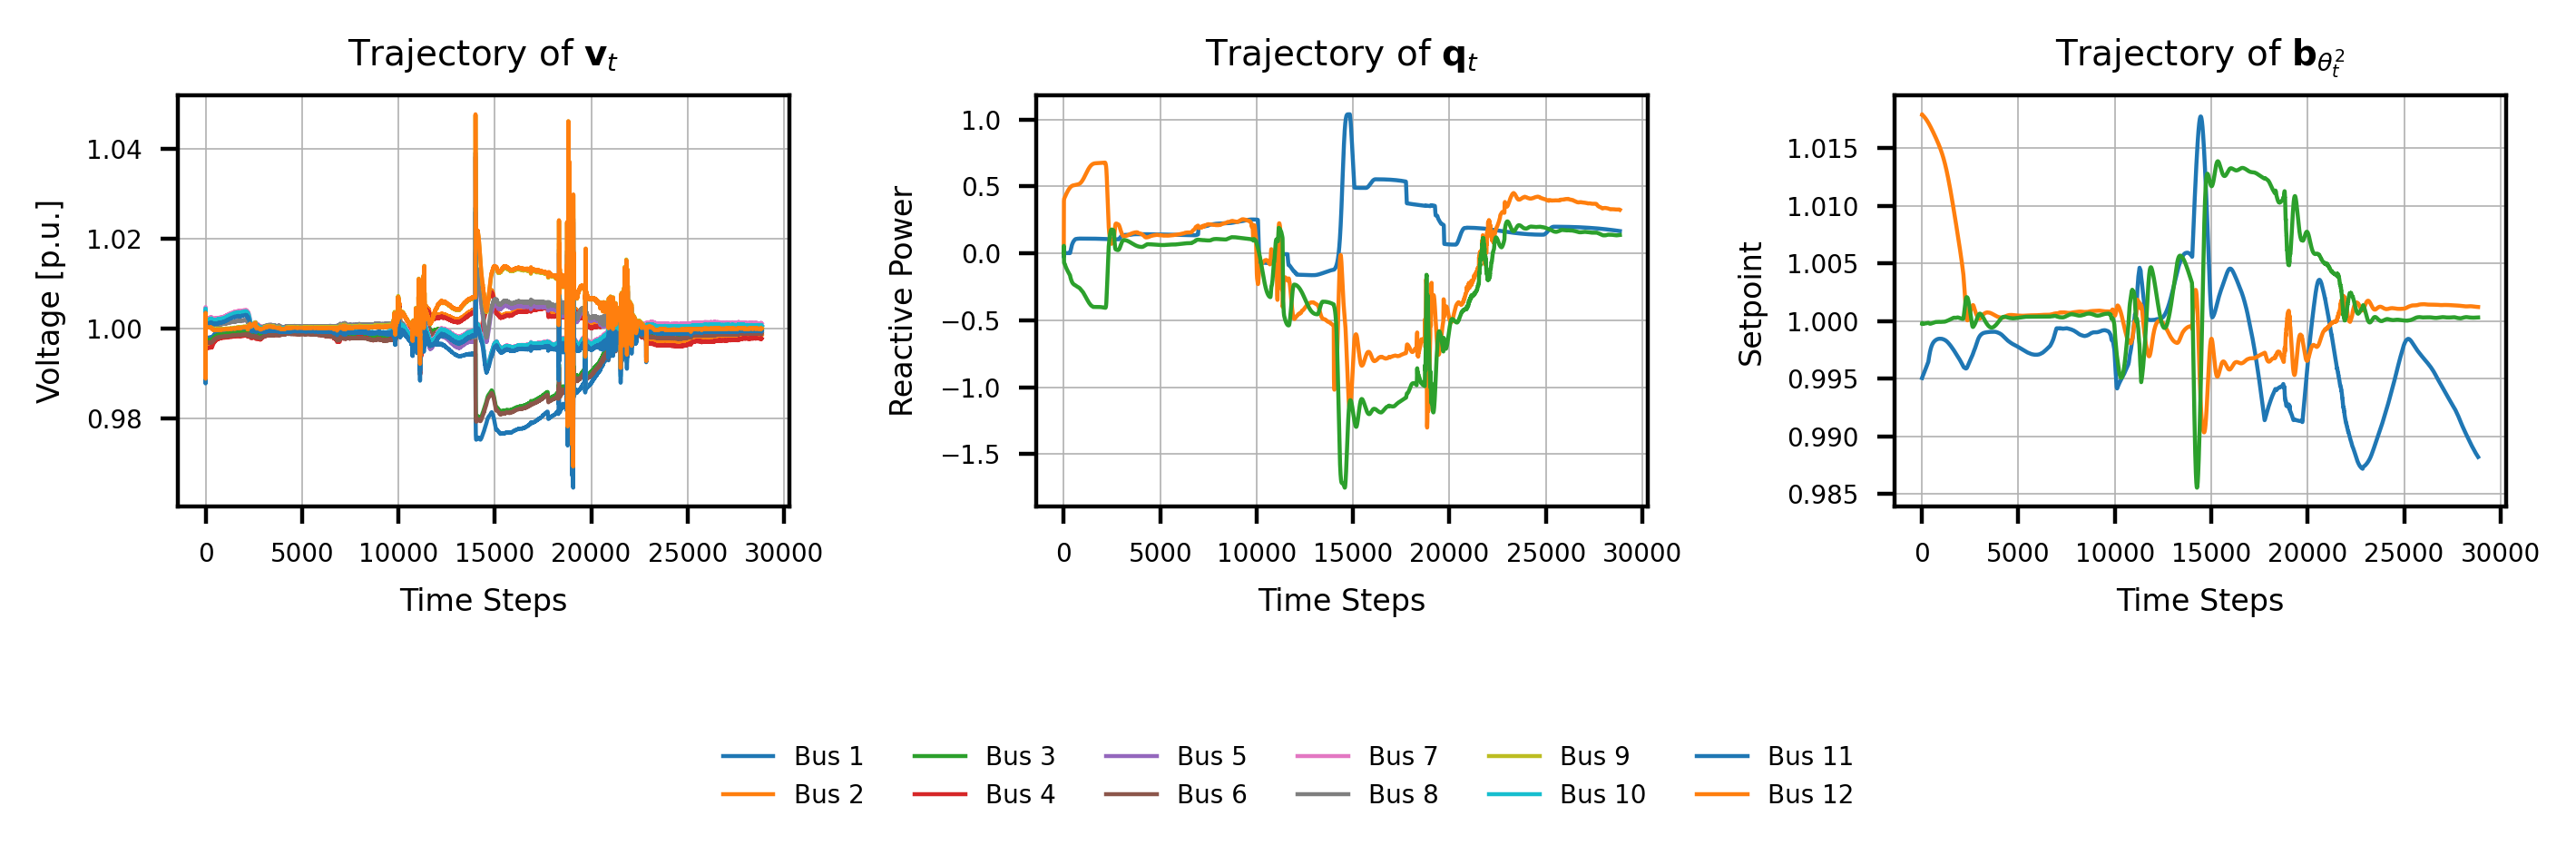

In [6]:
result_online = run_simulation(
    p_real,
    q_real,
    pv_p,
    enable_control=True,
    enable_online_update=True,
    enable_topo_update=True,
    apply_topo_change=True,
)

plot_trajectory_and_slopes(
    result_online["state_traj"],
    result_online["action_traj"],
    result_online["pp_traj"],
)

# np.save(output_dir / "state_traj_online.npy", result_online["state_traj"])
# np.save(output_dir / "action_traj_online.npy", result_online["action_traj"])
# np.save(output_dir / "pp_traj_online.npy", result_online["pp_traj"])


## 7. Scenario B: No online update (fixed policy)


In [ ]:
result_no_update = run_simulation(
    p_real,
    q_real,
    pv_p,
    enable_control=True,
    enable_online_update=False,
    enable_topo_update=False,
    apply_topo_change=True,
)

# np.save(output_dir / "state_traj_no_up.npy", result_no_update["state_traj"])
# np.save(output_dir / "action_traj_no_up.npy", result_no_update["action_traj"])
# np.save(output_dir / "pp_traj_no_up.npy", result_no_update["pp_traj"])


## 8. Scenario C: No control (topology change active)


In [ ]:
result_no_control = run_simulation(
    p_real,
    q_real,
    pv_p,
    enable_control=False,
    enable_online_update=False,
    enable_topo_update=False,
    apply_topo_change=True,
)

plot_trajectory_and_slopes(
    result_no_control["state_traj"],
    result_no_control["action_traj"],
    result_no_control["pp_traj"],
)

# np.save(output_dir / "state_traj_no_ct_tp.npy", result_no_control["state_traj"])


## 9. Scenario D: No control and no topology change


In [ ]:
result_no_control_no_topo = run_simulation(
    p_real,
    q_real,
    pv_p,
    enable_control=False,
    enable_online_update=False,
    enable_topo_update=False,
    apply_topo_change=False,
)

# np.save(output_dir / "state_traj_no_ct_no_tp.npy", result_no_control_no_topo["state_traj"])
